
# VQA Text EDA — Train / Dev / Test

## 목적

이미지 자체는 보지 않고 **텍스트 정보만으로** 데이터 분포를 분석한다.

특히 이 데이터셋에서는:

- **train / test**: 5명 중 4명 이상이 같은 선택지를 고른 비교적 명확한 샘플
- **dev**: 평가자 선택이 2/3 등으로 갈리는 상대적으로 모호한 샘플

이라는 차이가 있으므로 다음 질문에 답하는 것을 목표로 한다.

1. Train / Test의 질문과 선택지 길이 및 형태가 비슷한가?
2. 질문 유형 분포가 비슷한가?
3. Train의 정답 위치(`a/b/c/d`) 편향이 있는가?
4. 선택지 구성 자체에 정답을 추론할 수 있는 textual bias가 있는가?
5. Dev의 낮은 합의도가 질문/선택지 텍스트 특성과 관계가 있는가?
6. Train / Test를 텍스트만으로 구분할 수 있을 정도의 distribution shift가 있는가?
7. Train / Test 사이에 질문 또는 문제 텍스트 중복이 존재하는가?

> 주의: dev의 모호성은 이미지에서 발생할 수도 있으므로, 텍스트 EDA만으로 원인을 확정하지 않는다.


In [4]:

# 필요 패키지
# !pip install pandas numpy matplotlib scipy scikit-learn

from pathlib import Path
from collections import Counter
import math
import re
import unicodedata

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.stats import ks_2samp
from scipy.spatial.distance import jensenshannon

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.pipeline import Pipeline

pd.set_option("display.max_columns", 100)
pd.set_option("display.max_colwidth", 120)

SEED = 42



## 1. 데이터 로드

노트북과 CSV가 같은 폴더에 있으면 그대로 실행된다.  
ChatGPT sandbox에서 실행할 경우 `/mnt/data`도 자동 탐색한다.


In [5]:

def find_csv(name: str) -> Path:
    candidates = [
        Path(name),
        Path("data") / name,
        Path("../data") / name,  # eda/ 폴더에서 실행할 때
        Path("/mnt/data") / name,
    ]
    for path in candidates:
        if path.exists():
            return path
    raise FileNotFoundError(f"{name}을 찾을 수 없습니다.")

train = pd.read_csv(find_csv("train.csv"))
dev   = pd.read_csv(find_csv("dev.csv"))
test  = pd.read_csv(find_csv("test.csv"))

print("train:", train.shape)
print("dev  :", dev.shape)
print("test :", test.shape)

display(train.head(2))
display(dev.head(2))
display(test.head(2))


train: (6714, 8)
dev  : (2683, 12)
test : (6714, 7)


,id,path,question,a,b,c,d,answer
0,train_0001.jpg,train/train_0001.jpg,사진 속 선반에 적힌 문구는 무엇인가요?,SUNDAY BURGER LOVE,MONDAY SALAD TIME,FRIDAY PIZZA PARTY,WEDNESDAY SOUP DAY,a
1,train_0002.jpg,train/train_0002.jpg,이 식당 '오봉집'에서 판매하는 대표 메뉴는 무엇인가요?,직화낙지와 오봉보쌈,된장찌개와 불고기,김치찌개와 삼겹살,비빔밥과 김밥,a


,id,path,question,a,b,c,d,answer1,answer2,answer3,answer4,answer5
0,dev_0001.jpg,dev/dev_0001.jpg,이 인형뽑기 기계의 상호명은 무엇인가요?,JILL BY JILL STUART,PRIZE GAME,STUART,COCO ZZANG,d,d,NaN,d,a
1,dev_0002.jpg,dev/dev_0002.jpg,사진 속 초콜릿 매대에서 린트(Lindt) 초콜릿의 가격은 얼마인가요?,3.49,2.69,4.15,1.75,b,b,d,c,d


,id,path,question,a,b,c,d
0,test_0001.jpg,test/test_0001.jpg,이 사진 속 간판 중에서 '머리염색 체험방'이 적혀 있는 간판의 전화번호는 무엇인가요?,010-1234-5678,722-7510,123-4567,732-3258
1,test_0002.jpg,test/test_0002.jpg,이 식당 간판에 적힌 전문점의 종류는 무엇인가요?,중식 전문점,해산물 전문점,소고기숯불구이 전문점,한식 전문점



## 2. 기본 품질 검사

텍스트 EDA 전에 다음을 먼저 확인한다.

- 결측치
- 중복 ID
- 빈 질문 / 빈 선택지
- 정답 라벨 형식
- Dev annotator 응답 누락


In [6]:

TEXT_COLS = ["question", "a", "b", "c", "d"]

def basic_quality(df, name):
    print(f"\n[{name}]")
    print("rows:", len(df))
    print("duplicate id:", df["id"].duplicated().sum())
    print("\nmissing:")
    display(df.isna().sum().to_frame("missing"))

    empty = {}
    for col in TEXT_COLS:
        empty[col] = (
            df[col]
            .fillna("")
            .astype(str)
            .str.strip()
            .eq("")
            .sum()
        )
    print("empty text:")
    display(pd.Series(empty, name="count").to_frame())

for name, df in [("train", train), ("dev", dev), ("test", test)]:
    basic_quality(df, name)

print("train answer distribution:")
display(train["answer"].value_counts(dropna=False).sort_index())

DEV_ANSWER_COLS = [f"answer{i}" for i in range(1, 6)]
print("dev annotator missing counts:")
display(dev[DEV_ANSWER_COLS].isna().sum().to_frame("missing"))



[train]
rows: 6714
duplicate id: 0

missing:


,missing
id,0
path,0
question,0
a,0
b,0
c,0
d,0
answer,0


empty text:


,count
question,0
a,0
b,0
c,0
d,0



[dev]
rows: 2683
duplicate id: 0

missing:


...

,count
question,0
a,0
b,0
c,0
d,0


train answer distribution:


answer
a    1700
b    1644
c    1716
d    1654
Name: count, dtype: int64

dev annotator missing counts:


,missing
answer1,91
answer2,131
answer3,73
answer4,75
answer5,64



## 3. 텍스트 정규화 및 feature 생성

모델 tokenizer에 종속되지 않는 EDA를 위해 우선 다음 feature를 사용한다.

### 질문
- 문자 수
- 공백 기준 token 수
- 한글 / 영문 / 숫자 비율
- 숫자 포함 여부
- 물음표 포함 여부

### 선택지
- 각 선택지 문자 수
- 평균 / 최대 / 최소 길이
- 선택지 길이 범위
- 숫자형 선택지 개수

### 전체 문제
- `question + a/b/c/d`의 전체 문자 수

Tokenizer 기반 token length는 모델이 결정된 이후 별도 분석하는 것이 더 정확하다.


In [7]:

def normalize_text(x):
    x = "" if pd.isna(x) else str(x)
    x = unicodedata.normalize("NFKC", x)
    x = re.sub(r"\s+", " ", x).strip()
    return x

def whitespace_tokens(text):
    return re.findall(r"\S+", normalize_text(text))

def safe_ratio(pattern, text):
    text = normalize_text(text)
    if not text:
        return 0.0
    return len(re.findall(pattern, text)) / len(text)

def add_text_features(df):
    out = df.copy()

    for col in TEXT_COLS:
        out[f"{col}_norm"] = out[col].map(normalize_text)
        out[f"{col}_char_len"] = out[f"{col}_norm"].str.len()
        out[f"{col}_word_len"] = out[f"{col}_norm"].map(lambda x: len(whitespace_tokens(x)))

    out["question_korean_ratio"] = out["question_norm"].map(
        lambda x: safe_ratio(r"[가-힣]", x)
    )
    out["question_english_ratio"] = out["question_norm"].map(
        lambda x: safe_ratio(r"[A-Za-z]", x)
    )
    out["question_digit_ratio"] = out["question_norm"].map(
        lambda x: safe_ratio(r"\d", x)
    )
    out["question_has_digit"] = out["question_norm"].str.contains(r"\d", regex=True)
    out["question_has_question_mark"] = out["question_norm"].str.contains(r"\?", regex=True)

    option_len_cols = [f"{c}_char_len" for c in ["a", "b", "c", "d"]]
    out["option_char_mean"] = out[option_len_cols].mean(axis=1)
    out["option_char_min"] = out[option_len_cols].min(axis=1)
    out["option_char_max"] = out[option_len_cols].max(axis=1)
    out["option_char_range"] = out["option_char_max"] - out["option_char_min"]

    def is_numeric_like(x):
        x = normalize_text(x)
        # 가격, 전화번호, 숫자/단위형 등 넓게 탐지
        return bool(re.fullmatch(r"[\d\s.,:%+\-~/₩$€£원개명시분초cmkgmlL]+", x, flags=re.I))

    out["numeric_option_count"] = out[["a", "b", "c", "d"]].apply(
        lambda row: sum(is_numeric_like(v) for v in row),
        axis=1,
    )

    out["full_text"] = (
        out["question_norm"] + " [A] " + out["a_norm"]
        + " [B] " + out["b_norm"]
        + " [C] " + out["c_norm"]
        + " [D] " + out["d_norm"]
    )
    out["full_text_char_len"] = out["full_text"].str.len()

    return out

train_f = add_text_features(train)
dev_f   = add_text_features(dev)
test_f  = add_text_features(test)

FEATURE_COLS = [
    "question_char_len",
    "question_word_len",
    "question_korean_ratio",
    "question_english_ratio",
    "question_digit_ratio",
    "option_char_mean",
    "option_char_max",
    "option_char_range",
    "numeric_option_count",
    "full_text_char_len",
]

display(train_f[FEATURE_COLS].describe().T)


,count,mean,std,min,25%,50%,75%,max
question_char_len,6714.0,31.831546,10.243021,12.000000,25.000000,30.000000,38.00,107.000000
question_word_len,6714.0,7.873697,2.517417,3.000000,6.000000,8.000000,9.00,22.000000
question_korean_ratio,6714.0,0.711862,0.068373,0.207792,0.702128,0.729167,0.75,0.857143
question_english_ratio,6714.0,0.016694,0.059250,0.000000,0.000000,0.000000,0.00,0.571429
question_digit_ratio,6714.0,0.007142,0.023644,0.000000,0.000000,0.000000,0.00,0.250000
option_char_mean,6714.0,8.879990,6.275962,1.000000,4.750000,7.000000,11.25,76.750000
option_char_max,6714.0,10.989574,8.148072,1.000000,6.000000,9.000000,14.00,109.000000
option_char_range,6714.0,3.803843,5.013532,0.000000,1.000000,2.000000,5.00,80.000000
numeric_option_count,6714.0,0.574322,1.389851,0.000000,0.000000,0.000000,0.00,4.000000
full_text_char_len,6714.0,87.351504,28.350613,40.000000,68.000000,80.000000,99.00,391.000000



## 4. Train / Dev / Test 길이 분포 비교

먼저 가장 해석하기 쉬운 기본 분포를 비교한다.

- question 길이
- option 평균 길이
- 전체 prompt 길이

Dev가 유독 길거나 선택지가 비슷하게 길다면 모호성의 한 단서일 수 있다.


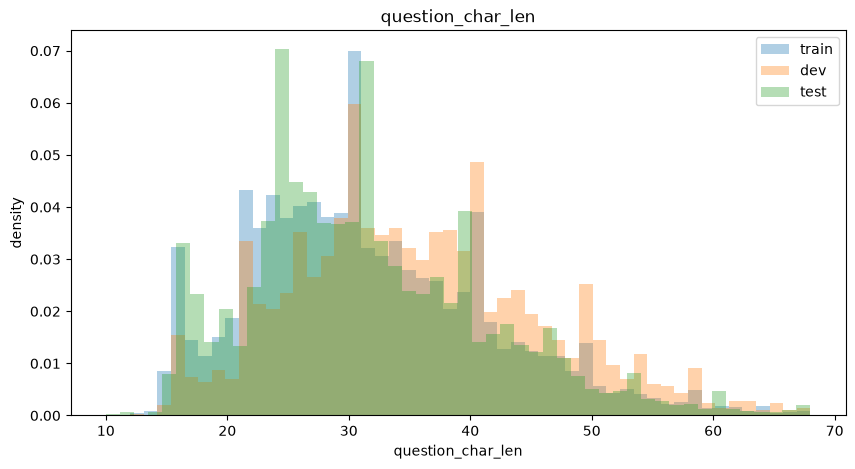

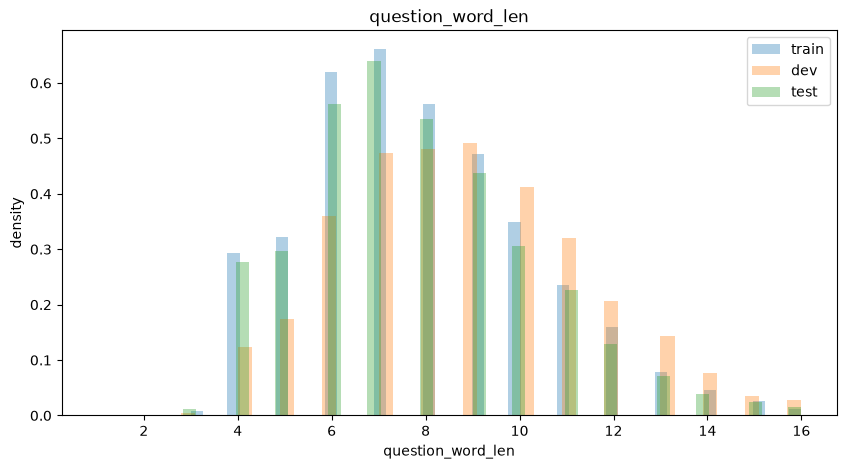

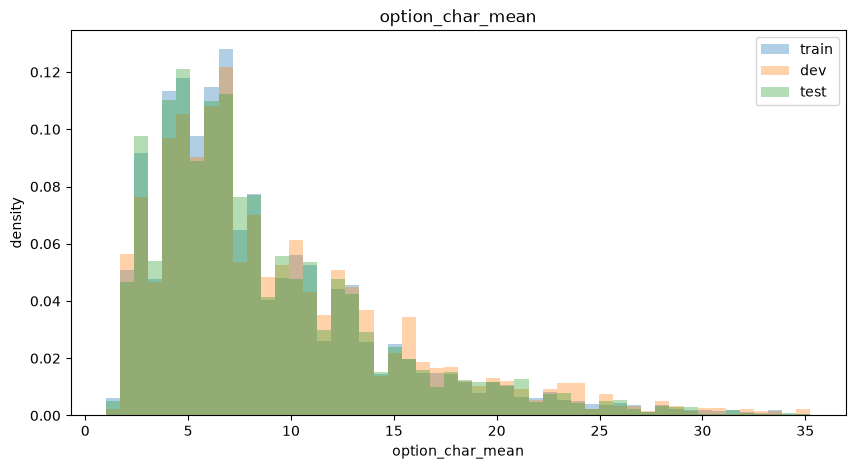

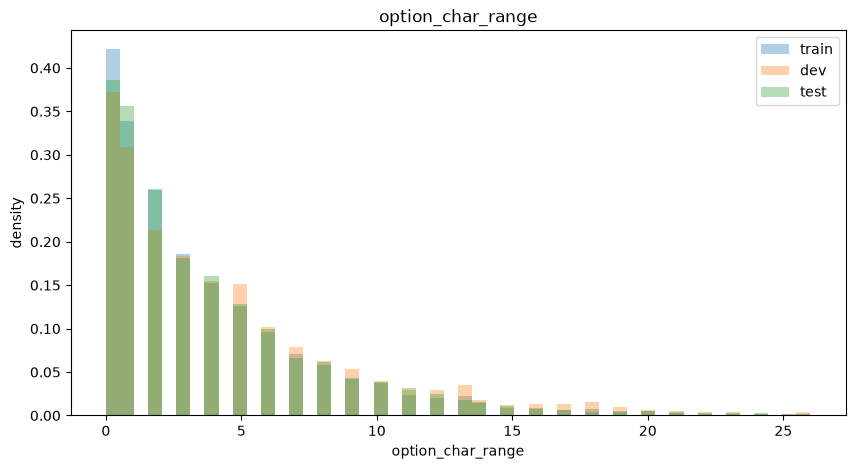

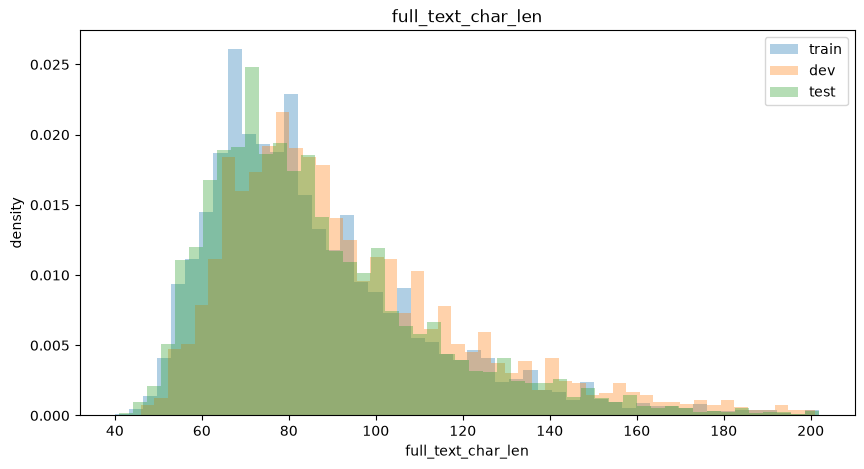

In [8]:

def plot_feature(feature, bins=50, clip_q=0.995):
    frames = {
        "train": train_f,
        "dev": dev_f,
        "test": test_f,
    }

    all_values = pd.concat(
        [df[feature] for df in frames.values()],
        ignore_index=True,
    ).dropna()

    xmax = all_values.quantile(clip_q)

    plt.figure(figsize=(10, 5))

    for name, df in frames.items():
        values = df.loc[df[feature] <= xmax, feature].dropna()
        plt.hist(
            values,
            bins=bins,
            density=True,
            alpha=0.35,
            label=name,
        )

    plt.title(feature)
    plt.xlabel(feature)
    plt.ylabel("density")
    plt.legend()
    plt.show()

for feature in [
    "question_char_len",
    "question_word_len",
    "option_char_mean",
    "option_char_range",
    "full_text_char_len",
]:
    plot_feature(feature)


In [9]:

# 요약 통계
summary_rows = []

for split_name, df in [
    ("train", train_f),
    ("dev", dev_f),
    ("test", test_f),
]:
    for feature in FEATURE_COLS:
        s = df[feature].dropna()
        summary_rows.append({
            "split": split_name,
            "feature": feature,
            "mean": s.mean(),
            "std": s.std(),
            "median": s.median(),
            "p90": s.quantile(0.90),
            "p99": s.quantile(0.99),
        })

summary = pd.DataFrame(summary_rows)
display(summary.round(3))


,split,feature,mean,std,median,p90,p99
0,train,question_char_len,31.832,10.243,30.000,46.000,61.870
1,train,question_word_len,7.874,2.517,8.000,11.000,15.000
2,train,question_korean_ratio,0.712,0.068,0.729,0.765,0.800
3,train,question_english_ratio,0.017,0.059,0.000,0.033,0.316
4,train,question_digit_ratio,0.007,0.024,0.000,0.029,0.121
5,train,option_char_mean,8.880,6.276,7.000,16.750,31.000
6,train,option_char_max,10.990,8.148,9.000,21.000,39.000
7,train,option_char_range,3.804,5.014,2.000,9.000,22.000
8,train,numeric_option_count,0.574,1.390,0.000,4.000,4.000
9,train,full_text_char_len,87.352,28.351,80.000,123.000,185.870



## 5. Train / Test numeric feature shift

Train과 Test가 실제 평가 분포이므로 가장 중요한 비교이다.

두 가지를 함께 본다.

- **KS statistic**: 두 연속형 분포의 형태 차이
- **Standardized Mean Difference (SMD)**: 평균 차이를 표준편차 단위로 표현

표본 수가 크므로 p-value만 보면 작은 차이도 유의하게 나올 수 있다.  
따라서 `KS statistic`, `SMD`, 실제 plot을 함께 해석한다.


In [10]:

def standardized_mean_diff(x, y):
    x = pd.Series(x).dropna().astype(float)
    y = pd.Series(y).dropna().astype(float)

    pooled_var = (x.var(ddof=1) + y.var(ddof=1)) / 2
    if pooled_var == 0:
        return 0.0

    return (x.mean() - y.mean()) / np.sqrt(pooled_var)

shift_rows = []

for feature in FEATURE_COLS:
    x = train_f[feature].dropna()
    y = test_f[feature].dropna()

    ks = ks_2samp(x, y)

    shift_rows.append({
        "feature": feature,
        "train_mean": x.mean(),
        "test_mean": y.mean(),
        "SMD(train-test)": standardized_mean_diff(x, y),
        "KS_stat": ks.statistic,
        "KS_pvalue": ks.pvalue,
    })

shift_numeric = pd.DataFrame(shift_rows).sort_values(
    "KS_stat",
    ascending=False,
)

display(shift_numeric.round(4))


,feature,train_mean,test_mean,SMD(train-test),KS_stat,KS_pvalue
7,option_char_range,3.8038,3.7690,0.0074,0.0177,0.2423
2,question_korean_ratio,0.7119,0.7133,-0.0209,0.0176,0.2509
5,option_char_mean,8.8800,8.8458,0.0056,0.0147,0.4588
0,question_char_len,31.8315,31.7398,0.0090,0.0147,0.4588
6,option_char_max,10.9896,10.9492,0.0051,0.0127,0.6550
4,question_digit_ratio,0.0071,0.0068,0.0148,0.0109,0.8223
9,full_text_char_len,87.3515,87.1230,0.0083,0.0100,0.8918
8,numeric_option_count,0.5743,0.5374,0.0270,0.0098,0.9019
1,question_word_len,7.8737,7.8509,0.0090,0.0080,0.9817
3,question_english_ratio,0.0167,0.0167,-0.0001,0.0076,0.9902



## 6. 질문 유형 분포

VQA에서 단순 길이보다 중요한 것은 **어떤 종류의 질문이 얼마나 나오는가**이다.

아래 분류는 정답용 classifier가 아니라 EDA용 rule-based taxonomy이다.

예:

- OCR / text reading
- number / price / phone
- counting
- color
- spatial
- object / category
- action / state
- other

한 질문이 여러 특성을 가질 수 있지만, EDA 단순화를 위해 우선순위 기반으로 하나의 유형만 부여한다.


,train,dev,test
question_type,,,
ocr_text,46.50,37.46,46.08
object_category,15.83,21.32,17.22
price,13.36,14.46,12.88
other,9.71,9.39,9.67
spatial,8.89,10.70,8.79
phone,3.32,3.39,3.10
action_state,1.12,1.23,0.92
color,0.64,1.27,0.89
counting,0.63,0.78,0.45


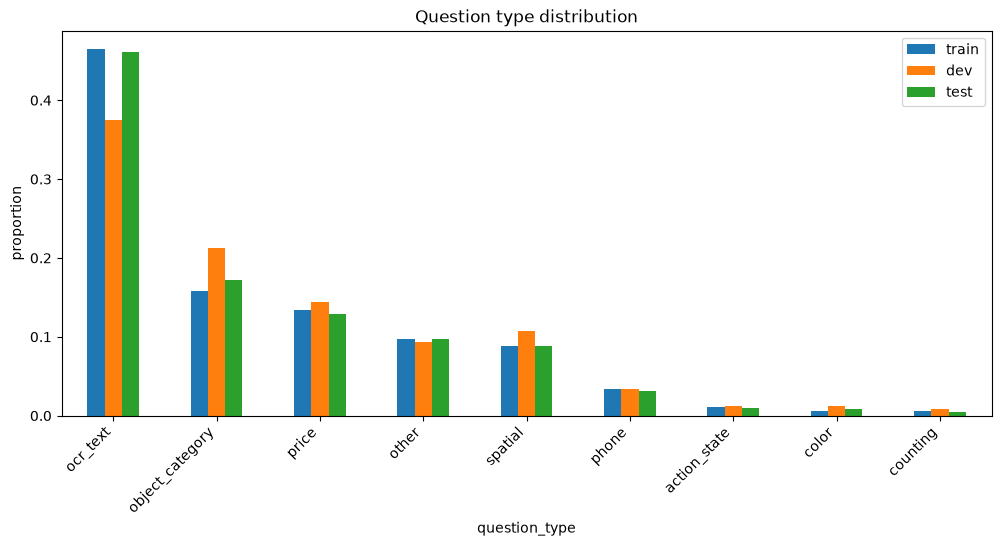

In [11]:

QUESTION_RULES = [
    (
        "phone",
        r"전화번호|연락처|휴대폰|핸드폰",
    ),
    (
        "price",
        r"가격|얼마|금액|원인가|원입니까",
    ),
    (
        "counting",
        r"몇\s*(개|명|마리|대|장|병|권)|개수|수량|몇인가|몇\s*인가",
    ),
    (
        "color",
        r"무슨\s*색|어떤\s*색|색상|색깔",
    ),
    (
        "spatial",
        r"어디|위치|왼쪽|오른쪽|위쪽|아래쪽|앞|뒤|옆",
    ),
    (
        "ocr_text",
        r"적힌|써\s*있|쓰여|문구|글자|상호명|간판|메뉴판|표지판|이름은|명칭|브랜드",
    ),
    (
        "action_state",
        r"무엇을\s*하고|뭐하고|행동|상태|하고\s*있|입고\s*있|들고\s*있",
    ),
    (
        "object_category",
        r"무엇인가|무엇인가요|무엇입니까|종류|어떤\s*것|어떤\s*제품|어떤\s*메뉴",
    ),
]

def classify_question(text):
    text = normalize_text(text)

    for label, pattern in QUESTION_RULES:
        if re.search(pattern, text, flags=re.I):
            return label

    return "other"

for df in [train_f, dev_f, test_f]:
    df["question_type"] = df["question_norm"].map(classify_question)

type_table = pd.concat(
    {
        "train": train_f["question_type"].value_counts(normalize=True),
        "dev": dev_f["question_type"].value_counts(normalize=True),
        "test": test_f["question_type"].value_counts(normalize=True),
    },
    axis=1,
).fillna(0)

display((type_table * 100).round(2).rename_axis("question_type"))

type_table.plot(
    kind="bar",
    figsize=(12, 5),
)
plt.ylabel("proportion")
plt.title("Question type distribution")
plt.xticks(rotation=45, ha="right")
plt.show()



### 질문 유형 Train/Test 차이를 Jensen-Shannon distance로 요약

- 0에 가까울수록 분포가 유사
- 값이 커질수록 차이가 큼

절대적인 합격/불합격 기준으로 쓰기보다는 실험 간 비교 지표로 사용한다.


In [12]:

def js_distance_from_counts(a, b):
    keys = sorted(set(a.index) | set(b.index))

    pa = a.reindex(keys, fill_value=0).astype(float).values
    pb = b.reindex(keys, fill_value=0).astype(float).values

    pa = pa / pa.sum()
    pb = pb / pb.sum()

    return jensenshannon(pa, pb, base=2)

train_type_counts = train_f["question_type"].value_counts()
test_type_counts = test_f["question_type"].value_counts()

print(
    "Question type JS distance (train vs test):",
    round(js_distance_from_counts(train_type_counts, test_type_counts), 4)
)


Question type JS distance (train vs test): 0.0246



## 7. 질문 표면형 분석

한국어 질문 데이터에서는 자주 등장하는 시작/종결 표현이 데이터 생성 규칙을 드러낼 수 있다.

특히 Train/Test에서 특정 template 비율이 크게 다르면 distribution shift일 수 있다.


In [13]:

def top_prefixes(series, n_chars=12, top_k=30):
    return (
        series.map(normalize_text)
        .str[:n_chars]
        .value_counts()
        .head(top_k)
        .rename("count")
        .to_frame()
    )

print("[train top question prefixes]")
display(top_prefixes(train["question"]))

print("[dev top question prefixes]")
display(top_prefixes(dev["question"]))

print("[test top question prefixes]")
display(top_prefixes(test["question"]))


[train top question prefixes]


,count
question,
이 가게의 이름은 무엇,63
사진 속 간판에 적힌,62
이 건물에 입주해 있는,52
이 건물의 이름은 무엇,35
이 건물의 간판에 적힌,30
이 가게의 간판에 적힌,30
이 가게의 상호명은 무,29
이 책의 제목은 무엇인,29
이 사진에 보이는 간판,29


[dev top question prefixes]


,count
question,
이 건물에 입주해 있는,34
사진 속 간판에 적힌,26
사진 속 건물에 적힌,18
다음 중 이미지 속 책,15
이 건물 2층에 위치한,15
다음 중 이미지에 보이,15
이 가게의 이름은 무엇,13
이 가게의 간판에 적힌,11
이 가게에서 판매하는,9


[test top question prefixes]


,count
question,
사진 속 간판에 적힌,62
이 가게의 이름은 무엇,60
이 건물에 입주해 있는,48
이 가게의 간판에 적힌,43
이 건물의 이름은 무엇,39
이 사진에 보이는 간판,32
이 건물의 간판에 적힌,31
이 가게의 상호명은 무,28
이 건물 간판에 적힌,25


In [14]:

# 자주 등장하는 공백 token
STOPWORDS = {
    "이", "그", "저", "있는", "사진", "속", "사진에서", "사진의",
    "무엇인가요", "무엇인가", "무엇입니까", "어떤", "것은", "있는가요",
}

def top_tokens(series, top_k=40):
    counter = Counter()

    for text in series.fillna("").astype(str):
        tokens = re.findall(r"[가-힣A-Za-z0-9]+", normalize_text(text).lower())
        counter.update(t for t in tokens if len(t) > 1 and t not in STOPWORDS)

    return pd.DataFrame(
        counter.most_common(top_k),
        columns=["token", "count"],
    )

for name, df in [
    ("train", train),
    ("dev", dev),
    ("test", test),
]:
    print(f"\n[{name}]")
    display(top_tokens(df["question"]))



[train]


,token,count
0,적힌,2173
1,이름은,1317
2,얼마인가요,795
3,보이는,631
4,간판에,565
5,가격은,507
6,사진에,400
7,있나요,398
8,문구는,386
9,적혀,382



[dev]


,token,count
0,적힌,833
1,이름은,325
2,얼마인가요,296
3,보이는,276
4,가격은,206
5,아닌,205
6,간판에,204
7,있나요,176
8,따르면,176
9,건물에,156



[test]


,token,count
0,적힌,2206
1,이름은,1294
2,얼마인가요,736
3,간판에,654
4,보이는,613
5,가격은,459
6,있나요,405
7,문구는,385
8,적혀,367
9,사진에,362



## 8. Train 정답 위치 편향

정답의 `a/b/c/d` 비율을 확인한다.

또한 정답 선택지가 오답보다 유독 길거나 짧은지 확인한다.  
이런 차이는 이미지 없이도 답을 맞힐 수 있는 **annotation artifact**가 될 수 있다.


,percent
answer,
a,25.32
b,24.49
c,25.56
d,24.64


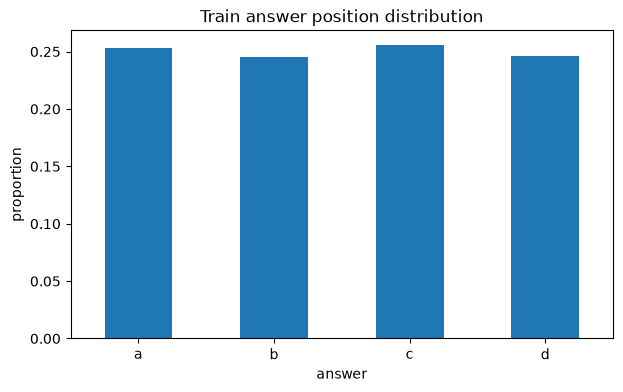

In [15]:

answer_dist = (
    train["answer"]
    .value_counts(normalize=True)
    .reindex(["a", "b", "c", "d"])
)

display((answer_dist * 100).round(2).rename("percent").to_frame())

answer_dist.plot(kind="bar", figsize=(7, 4))
plt.title("Train answer position distribution")
plt.ylabel("proportion")
plt.xticks(rotation=0)
plt.show()


,count,mean,std,min,25%,50%,75%,max
answer_char_len,6714.0,9.677093,7.681097,1.000000,5.000000,7.0,12.000000,109.000000
wrong_char_mean,6714.0,8.614289,6.067020,1.000000,4.666667,7.0,11.000000,77.000000
answer_minus_wrong_len,6714.0,1.062804,3.979054,-22.666667,-0.333333,0.0,1.666667,72.666667


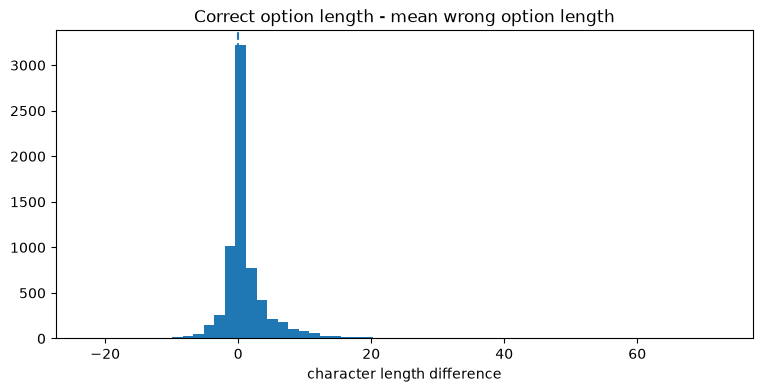

In [16]:

def get_answer_text(row):
    ans = str(row["answer"]).strip().lower()
    return normalize_text(row[ans]) if ans in {"a", "b", "c", "d"} else ""

train_bias = train_f.copy()
train_bias["answer_text"] = train_bias.apply(get_answer_text, axis=1)
train_bias["answer_char_len"] = train_bias["answer_text"].str.len()

def wrong_option_lengths(row):
    ans = str(row["answer"]).strip().lower()
    return [
        len(normalize_text(row[c]))
        for c in ["a", "b", "c", "d"]
        if c != ans
    ]

train_bias["wrong_char_mean"] = train_bias.apply(
    lambda r: np.mean(wrong_option_lengths(r)),
    axis=1,
)

train_bias["answer_minus_wrong_len"] = (
    train_bias["answer_char_len"]
    - train_bias["wrong_char_mean"]
)

display(
    train_bias[
        ["answer_char_len", "wrong_char_mean", "answer_minus_wrong_len"]
    ].describe().T
)

plt.figure(figsize=(9, 4))
plt.hist(
    train_bias["answer_minus_wrong_len"],
    bins=60,
)
plt.axvline(0, linestyle="--")
plt.title("Correct option length - mean wrong option length")
plt.xlabel("character length difference")
plt.show()



## 9. 선택지 간 lexical similarity

애매한 문제는 선택지들이 서로 매우 비슷하거나, 작은 숫자/단어 차이만 있을 수도 있다.

간단한 character bigram Jaccard similarity를 사용하여 한 문제 안에서 선택지들이 얼마나 비슷한지 측정한다.


,count,mean,std,min,25%,50%,75%,max
train,6714.0,0.162733,0.192155,0.0,0.0,0.077726,0.277778,0.933333
dev,2683.0,0.166119,0.197544,0.0,0.0,0.082143,0.279516,0.958333
test,6714.0,0.159653,0.187686,0.0,0.0,0.081400,0.266667,1.000000


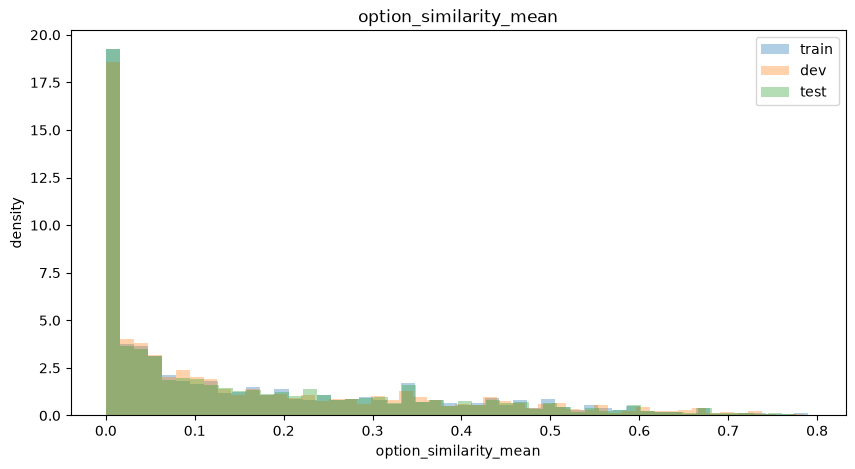

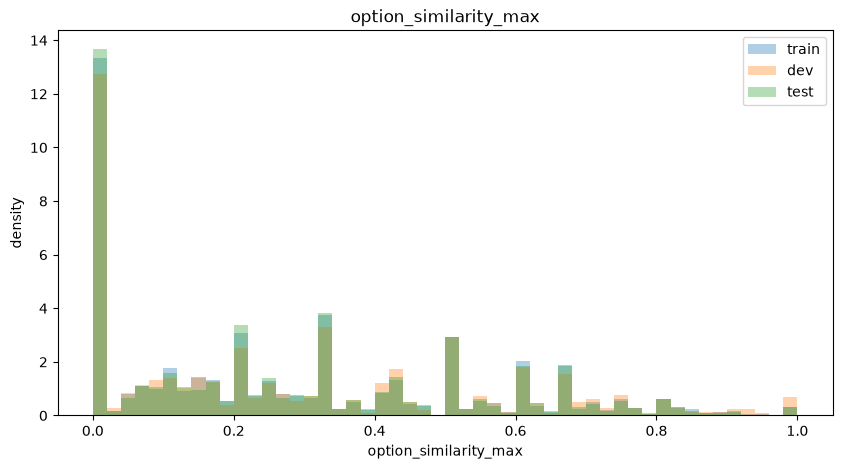

In [17]:

def char_ngrams(text, n=2):
    text = re.sub(r"\s+", "", normalize_text(text).lower())

    if len(text) < n:
        return {text} if text else set()

    return {
        text[i:i+n]
        for i in range(len(text) - n + 1)
    }

def jaccard(a, b):
    a = char_ngrams(a)
    b = char_ngrams(b)

    if not a and not b:
        return 1.0
    if not a or not b:
        return 0.0

    return len(a & b) / len(a | b)

def option_similarity_features(row):
    options = [row[c] for c in ["a", "b", "c", "d"]]

    sims = []
    for i in range(4):
        for j in range(i + 1, 4):
            sims.append(jaccard(options[i], options[j]))

    return pd.Series({
        "option_similarity_mean": np.mean(sims),
        "option_similarity_max": np.max(sims),
    })

for df in [train_f, dev_f, test_f]:
    df[["option_similarity_mean", "option_similarity_max"]] = df.apply(
        option_similarity_features,
        axis=1,
    )

display(
    pd.DataFrame({
        "train": train_f["option_similarity_mean"].describe(),
        "dev": dev_f["option_similarity_mean"].describe(),
        "test": test_f["option_similarity_mean"].describe(),
    }).T
)

plot_feature("option_similarity_mean")
plot_feature("option_similarity_max")



## 10. Dev annotator 합의도 분석

Dev에는 `answer1 ~ answer5`가 있으므로 텍스트 EDA와 연결할 수 있는 핵심 지표를 만든다.

- `vote_count`: 실제 응답자 수
- `top_vote_count`: 가장 많이 선택된 답의 득표 수
- `consensus_ratio`: `top_vote_count / vote_count`
- `vote_entropy`: 선택이 얼마나 분산되어 있는지
- `n_unique_votes`: 서로 다른 선택지 수
- `is_tie`: 공동 최다 득표가 존재하는지

Entropy가 높을수록 평가자의 판단이 더 분산되었다고 본다.


In [18]:

def vote_features(row):
    votes = [
        str(row[c]).strip().lower()
        for c in DEV_ANSWER_COLS
        if pd.notna(row[c])
        and str(row[c]).strip().lower() in {"a", "b", "c", "d"}
    ]

    counts = Counter(votes)

    if not counts:
        return pd.Series({
            "vote_count": 0,
            "top_vote_count": 0,
            "consensus_ratio": np.nan,
            "vote_entropy": np.nan,
            "n_unique_votes": 0,
            "is_tie": False,
            "majority_answer": None,
        })

    total = len(votes)
    values = np.array(list(counts.values()), dtype=float)
    probs = values / total

    entropy = -(probs * np.log2(probs)).sum()

    top = values.max()
    winners = [
        label
        for label, count in counts.items()
        if count == top
    ]

    return pd.Series({
        "vote_count": total,
        "top_vote_count": int(top),
        "consensus_ratio": top / total,
        "vote_entropy": entropy,
        "n_unique_votes": len(counts),
        "is_tie": len(winners) > 1,
        "majority_answer": winners[0] if len(winners) == 1 else "/".join(sorted(winners)),
    })

dev_vote = dev.apply(vote_features, axis=1)
dev_f = pd.concat([dev_f, dev_vote], axis=1)

display(
    dev_f[
        [
            "vote_count",
            "top_vote_count",
            "consensus_ratio",
            "vote_entropy",
            "n_unique_votes",
            "is_tie",
        ]
    ].describe(include="all")
)

print("\nTop vote count:")
display(dev_f["top_vote_count"].value_counts(dropna=False).sort_index().to_frame("count"))

print("\nConsensus ratio:")
display(dev_f["consensus_ratio"].value_counts(dropna=False).sort_index().to_frame("count"))

print("\nNumber of unique votes:")
display(dev_f["n_unique_votes"].value_counts(dropna=False).sort_index().to_frame("count"))


,vote_count,top_vote_count,consensus_ratio,vote_entropy,n_unique_votes,is_tie
count,2683.000000,2683.000000,2681.000000,2681.000000,2683.000000,2683
unique,NaN,NaN,NaN,NaN,NaN,2
top,NaN,NaN,NaN,NaN,NaN,False
freq,NaN,NaN,NaN,NaN,NaN,2218
mean,4.838241,2.751398,0.572616,1.203209,2.541558,NaN
std,0.415848,0.442513,0.104527,0.307213,0.598319,NaN
min,0.000000,0.000000,0.250000,-0.000000,0.000000,NaN
25%,5.000000,3.000000,0.600000,0.970951,2.000000,NaN
50%,5.000000,3.000000,0.600000,1.370951,3.000000,NaN
75%,5.000000,3.000000,0.600000,1.370951,3.000000,NaN



Top vote count:


,count
top_vote_count,
0,2
1,6
2,649
3,2026



Consensus ratio:


,count
consensus_ratio,
0.250000,5
0.333333,1
0.400000,528
0.500000,109
0.600000,1759
0.666667,12
0.750000,250
1.000000,17
NaN,2



Number of unique votes:


,count
n_unique_votes,
0,2
1,17
2,1314
3,1226
4,124


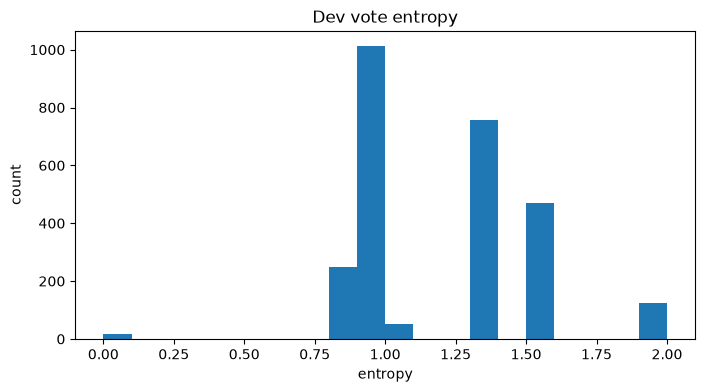

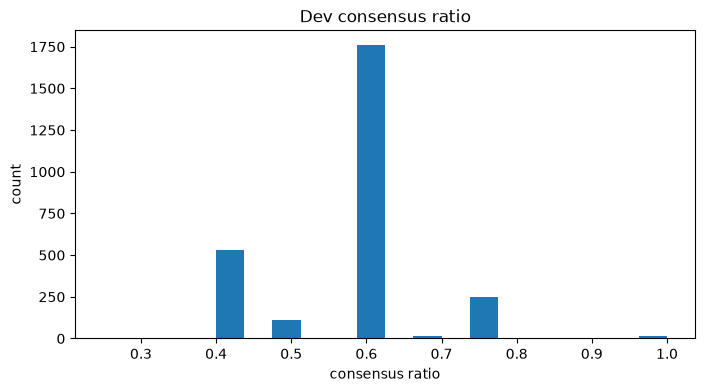

In [19]:

plt.figure(figsize=(8, 4))
plt.hist(
    dev_f["vote_entropy"].dropna(),
    bins=20,
)
plt.title("Dev vote entropy")
plt.xlabel("entropy")
plt.ylabel("count")
plt.show()

plt.figure(figsize=(8, 4))
plt.hist(
    dev_f["consensus_ratio"].dropna(),
    bins=20,
)
plt.title("Dev consensus ratio")
plt.xlabel("consensus ratio")
plt.ylabel("count")
plt.show()



## 11. Dev 모호성과 텍스트 특성의 관계

여기서는 **상관관계만** 본다.

`vote_entropy`가 높은 문제에서 다음 특성이 커지는지 확인한다.

- 질문 길이
- 선택지 길이 편차
- 선택지 간 similarity
- 숫자형 선택지 개수
- 질문 유형

중요: 상관이 없다고 해서 모호성 원인이 없는 것이 아니다.  
모호성은 이미지 자체, crop, 시인성, 장면 맥락 등 vision side에서 발생할 수 있다.


In [20]:

DEV_NUMERIC_FEATURES = [
    "question_char_len",
    "question_word_len",
    "option_char_mean",
    "option_char_range",
    "option_similarity_mean",
    "option_similarity_max",
    "numeric_option_count",
    "full_text_char_len",
]

corr = (
    dev_f[
        DEV_NUMERIC_FEATURES
        + ["vote_entropy", "consensus_ratio"]
    ]
    .corr(method="spearman")
    [["vote_entropy", "consensus_ratio"]]
    .drop(index=["vote_entropy", "consensus_ratio"])
)

display(corr.sort_values("vote_entropy", ascending=False).round(3))


,vote_entropy,consensus_ratio
question_char_len,0.084,-0.071
question_word_len,0.076,-0.063
full_text_char_len,0.036,-0.021
option_char_range,0.000,-0.012
option_char_mean,-0.008,0.015
numeric_option_count,-0.016,0.010
option_similarity_max,-0.025,0.009
option_similarity_mean,-0.029,0.024


In [21]:

dev_type_ambiguity = (
    dev_f.groupby("question_type")
    .agg(
        n=("id", "size"),
        vote_entropy_mean=("vote_entropy", "mean"),
        consensus_mean=("consensus_ratio", "mean"),
        option_similarity_mean=("option_similarity_mean", "mean"),
        question_length_mean=("question_char_len", "mean"),
    )
    .sort_values("vote_entropy_mean", ascending=False)
)

display(dev_type_ambiguity.round(3))


,n,vote_entropy_mean,consensus_mean,option_similarity_mean,question_length_mean
question_type,,,,,
action_state,33,1.238,0.574,0.119,44.424
object_category,572,1.236,0.569,0.101,36.986
color,34,1.232,0.547,0.118,46.088
price,388,1.221,0.566,0.295,36.843
spatial,287,1.210,0.566,0.104,36.878
counting,21,1.210,0.562,0.132,40.857
phone,91,1.191,0.586,0.247,34.670
other,252,1.189,0.571,0.202,38.298
ocr_text,1005,1.178,0.580,0.158,33.365



## 12. Train / Test 텍스트 중복 및 leakage 후보

세 수준으로 확인한다.

1. exact normalized question
2. `question + a/b/c/d` 전체 문제 exact match
3. split 내부 duplicate

Test 정답은 없으므로 이것 자체가 leakage를 의미하지는 않지만, 평가 분포를 이해하는 중요한 정보이다.


In [22]:

def normalized_problem_signature(df):
    return (
        df["question_norm"]
        + " || "
        + df["a_norm"]
        + " || "
        + df["b_norm"]
        + " || "
        + df["c_norm"]
        + " || "
        + df["d_norm"]
    )

for df in [train_f, dev_f, test_f]:
    df["problem_signature"] = normalized_problem_signature(df)

train_questions = set(train_f["question_norm"])
test_questions = set(test_f["question_norm"])

train_problems = set(train_f["problem_signature"])
test_problems = set(test_f["problem_signature"])

print(
    "Train/Test exact normalized question overlap:",
    len(train_questions & test_questions),
)

print(
    "Train/Test exact full problem overlap:",
    len(train_problems & test_problems),
)

for name, df in [
    ("train", train_f),
    ("dev", dev_f),
    ("test", test_f),
]:
    print(
        f"{name} duplicate question:",
        df["question_norm"].duplicated().sum(),
        "| duplicate full problem:",
        df["problem_signature"].duplicated().sum(),
    )


Train/Test exact normalized question overlap: 352
Train/Test exact full problem overlap: 1
train duplicate question: 625 | duplicate full problem: 0
dev duplicate question: 73 | duplicate full problem: 0
test duplicate question: 636 | duplicate full problem: 0



## 13. Train / Test를 텍스트만으로 구분할 수 있는가?

가장 중요한 distribution shift 검사 중 하나이다.

### 방법

`question + options`만 사용해 binary classifier를 학습한다.

- Train sample → label 0
- Test sample → label 1
- Character TF-IDF
- Logistic Regression
- 5-fold cross validation ROC-AUC

### 해석

대략적으로:

- **AUC ≈ 0.5**: 텍스트 표면형만으로 두 split을 구분하기 어려움
- **AUC가 뚜렷하게 높음**: Train/Test에 detectable textual shift가 존재

이는 성능 평가용 모델이 아니라 **dataset diagnostic**이다.


In [23]:

domain_df = pd.concat(
    [
        train_f[["full_text"]].assign(domain=0),
        test_f[["full_text"]].assign(domain=1),
    ],
    ignore_index=True,
)

domain_pipeline = Pipeline([
    (
        "tfidf",
        TfidfVectorizer(
            analyzer="char",
            ngram_range=(2, 5),
            min_df=3,
            max_features=50_000,
            sublinear_tf=True,
        ),
    ),
    (
        "clf",
        LogisticRegression(
            max_iter=1000,
            random_state=SEED,
        ),
    ),
])

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=SEED,
)

auc_scores = cross_val_score(
    domain_pipeline,
    domain_df["full_text"],
    domain_df["domain"],
    cv=cv,
    scoring="roc_auc",
    n_jobs=-1,
)

print("fold AUC:", np.round(auc_scores, 4))
print("mean AUC:", round(auc_scores.mean(), 4))
print("std AUC :", round(auc_scores.std(), 4))


fold AUC: [0.4997 0.5098 0.4983 0.5    0.4967]
mean AUC: 0.5009
std AUC : 0.0046



## 14. Train/Test를 구분하는 대표적인 character n-gram

Domain classifier를 전체 데이터에 다시 학습하여 어느 표현이 Train/Test를 구분하는지 확인한다.

- coefficient < 0: Train 쪽에서 상대적으로 강함
- coefficient > 0: Test 쪽에서 상대적으로 강함

이 결과는 단어의 의미보다는 **template / 표기 방식 / 특정 주제 편향**을 찾는 용도이다.


In [24]:

domain_pipeline.fit(
    domain_df["full_text"],
    domain_df["domain"],
)

vectorizer = domain_pipeline.named_steps["tfidf"]
classifier = domain_pipeline.named_steps["clf"]

features = np.array(vectorizer.get_feature_names_out())
coef = classifier.coef_[0]

top_n = 40

train_idx = np.argsort(coef)[:top_n]
test_idx = np.argsort(coef)[-top_n:][::-1]

distinguishing = pd.DataFrame({
    "train_associated_ngram": features[train_idx],
    "train_coef": coef[train_idx],
    "test_associated_ngram": features[test_idx],
    "test_coef": coef[test_idx],
})

display(distinguishing)


,train_associated_ngram,train_coef,test_associated_ngram,test_coef
0,열,-1.060523,정,1.140806
1,승,-0.992155,2,0.954701
2,료,-0.947466,차,0.904108
3,s [,-0.844396,판에 적혀,0.844227
4,중 ',-0.839466,el,0.821083
5,중 ',-0.820678,동,0.804435
6,된,-0.752622,] 100,0.803459
7,',-0.745294,a] 2,0.756688
8,[b] 8,-0.741842,[a] 2,0.756688
9,b] 8,-0.741842,100,0.744188



## 15. Dev와 명확한 데이터의 텍스트 차이

Dev는 ambiguous set이므로 `train`과 비교해서 **텍스트만으로도 dev를 구분할 수 있는지** 확인한다.

단, train/dev의 데이터 생성 과정이나 split 규칙 자체가 다르면 classifier는 모호성 이외의 차이도 학습할 수 있다.  
따라서 결과는 "ambiguity predictor"가 아니라 **diagnostic signal**로 해석한다.


In [25]:

amb_df = pd.concat(
    [
        train_f[["full_text"]].assign(ambiguous=0),
        dev_f[["full_text"]].assign(ambiguous=1),
    ],
    ignore_index=True,
)

amb_pipeline = Pipeline([
    (
        "tfidf",
        TfidfVectorizer(
            analyzer="char",
            ngram_range=(2, 5),
            min_df=3,
            max_features=50_000,
            sublinear_tf=True,
        ),
    ),
    (
        "clf",
        LogisticRegression(
            max_iter=1000,
            class_weight="balanced",
            random_state=SEED,
        ),
    ),
])

amb_auc = cross_val_score(
    amb_pipeline,
    amb_df["full_text"],
    amb_df["ambiguous"],
    cv=cv,
    scoring="roc_auc",
    n_jobs=-1,
)

print("fold AUC:", np.round(amb_auc, 4))
print("mean AUC:", round(amb_auc.mean(), 4))
print("std AUC :", round(amb_auc.std(), 4))


fold AUC: [0.6151 0.6281 0.6411 0.6285 0.6192]
mean AUC: 0.6264
std AUC : 0.009



## 16. 최종 요약표

마지막으로 실험 기록에 붙여넣기 쉬운 형태로 주요 지표를 한 번에 출력한다.


In [26]:

report = {
    "n_train": len(train_f),
    "n_dev": len(dev_f),
    "n_test": len(test_f),

    "train_question_len_mean": train_f["question_char_len"].mean(),
    "dev_question_len_mean": dev_f["question_char_len"].mean(),
    "test_question_len_mean": test_f["question_char_len"].mean(),

    "train_option_len_mean": train_f["option_char_mean"].mean(),
    "dev_option_len_mean": dev_f["option_char_mean"].mean(),
    "test_option_len_mean": test_f["option_char_mean"].mean(),

    "train_test_question_exact_overlap": len(train_questions & test_questions),
    "train_test_full_problem_exact_overlap": len(train_problems & test_problems),

    "dev_vote_entropy_mean": dev_f["vote_entropy"].mean(),
    "dev_consensus_ratio_mean": dev_f["consensus_ratio"].mean(),

    "train_test_domain_auc_mean": auc_scores.mean(),
    "train_dev_ambiguity_auc_mean": amb_auc.mean(),

    "question_type_js_distance_train_test": js_distance_from_counts(
        train_type_counts,
        test_type_counts,
    ),
}

report_df = pd.Series(report, name="value").to_frame()
display(report_df.round(4))


,value
n_train,6714.0000
n_dev,2683.0000
n_test,6714.0000
train_question_len_mean,31.8315
dev_question_len_mean,35.8792
test_question_len_mean,31.7398
train_option_len_mean,8.8800
dev_option_len_mean,9.6451
test_option_len_mean,8.8458
train_test_question_exact_overlap,352.0000



# 해석 체크리스트

노트북 실행 후 다음 순서로 판단한다.

### 1. Train/Test 기본 분포
- question / option 길이가 유사한가?
- 숫자형 선택지 비율이 유사한가?
- 질문 유형 비율이 유사한가?

### 2. Train annotation artifact
- 정답 위치가 `a/b/c/d` 중 특정 위치에 몰리는가?
- 정답 선택지가 오답보다 체계적으로 길거나 짧은가?

### 3. Dev ambiguity
- entropy가 높은 문제에서 선택지 lexical similarity가 증가하는가?
- 특정 질문 유형에서 entropy가 높은가?
- 긴 질문 또는 숫자형 문제에서 합의율이 달라지는가?

### 4. Train/Test domain shift
- numeric feature의 KS statistic이 큰 항목은 무엇인가?
- TF-IDF domain classifier AUC가 0.5에서 크게 벗어나는가?
- 어떤 n-gram/template이 split을 구분하는가?

### 5. Leakage / overlap
- Train/Test exact question overlap이 있는가?
- 전체 문제(question + options)가 동일한 샘플이 있는가?

## 이후 권장 분석

텍스트 EDA 다음 단계에서는 별도 notebook에서 다음을 수행하는 것이 좋다.

- 이미지 해상도 / aspect ratio
- 밝기 / blur / OCR text density
- vision embedding Train/Test shift
- 이미지 중복 / near-duplicate
- **text ambiguity × image quality** 교차 분석
